In [1]:
#-----#
#Used for nested sweeping of Keithley SMUs, for recording I,V from Keithleys and Nanovoltmeters
#Using QCodes for data storage, 
#Use plottr-inspectr for real-time plotting (open separately)

#Created by Lewis P. and Eli H
#Updated 16/10/2025


###NANOVOLTMETERS NOT SUPPORTED



In [2]:
measure_V = True


#just imports helper functions software
from import_all import *
from utilities import *
import trigger_fns_v as trigger_fns_v
import trigger_fns as trigger_fns
from pathlib import Path


In [3]:
#----Connect to instrument----#
#load the station from yaml configuration file
station = Station(config_file="electrochemistry.station.yaml")
keithley1 = station.load_keithley1()
keithley2 = station.load_keithley2()

keithleys = [keithley1]


Connected to: Keithley Instruments Inc. 2636B (serial:4629010, firmware:3.4.0) in 0.11s
Connected to: Keithley Instruments Inc. 2614B (serial:4070377, firmware:3.0.4) in 0.14s


In [4]:
#---Save paths----#
csv_save_path = "../csv/test/"
db_save_path = "../db/test/"
device_name = "test2" #master database file
xpmnt_name = "test2"#xpmnt name within database. Saved as seperate csv
csv_path = Path(csv_save_path)
db_path = Path(db_save_path)

In [5]:
####################################
#----Configure channels----#
####################################
keithleys = [keithley1,keithley2]
ch1 = { "channel": keithley1.smua,
        "name": "top_gate", 
        "first_node": -1, # from start -> first_node -> second_node -> start
        "second_node": 1,
        "start": 0,
        "step": 0.1, #voltage step
        "independent": True,  #independent variable for plotting purposes? Can be buggy if more than one independent variable
        "manual": False,
        "manual_scanrange": [],
        "mode": "i",
               
}


ch2 = { "channel": keithley1.smub,
        "name": "bot_gate",
        "first_node": -1, # from start -> first_node -> second_node -> start
        "second_node": 1,
        "start": 0,
        "step": 0.1, #voltage step
        "independent": not False,  #independent variable for plotting purposes? Can be buggy if more than one independent variable
        "manual": False,
        "manual_scanrange": [],
        "mode": "v",
}

ch3 = { "channel": keithley2.smua,
        "name": "drain_source",
        "first_node":0.01,
        "second_node": 0.01,
        "start":0.01,
        "step": 0.0,
        "independent":  False,
        "manual": False,
        "manual_scanrange": [],
        "mode": "v",

}

# ch4 = { "channel": keithley2.smua,
#         "name": "temperature", #handled differently. If measuring temperature, make sure to include "temperature" in name
#         "first_node":5e-3,
#         "second_node": 5e-3,
#         "start":5e-3,
#         "step": 0,
#         "independent":  False,
#         "manual": False,
#         "manual_scanrange": [],
        # "mode": "i",

# }


####################################
#----Configure sweeping params----#
####################################
time_independent = False  #plot time as indepent variable?

ramp_up = not True # ramp to initial values?
ramp_down = not True #ramp back to 0?

temp_measure = True

ktime_control = True

dt_list = [0.1]
dt = dt_list[0] #time per point in seconds

delayNPLC_ratio = 0.9 #ratio of delay to total time dt.

start_delay = 1
write_period = 2
repeat= 1
round_delay= 0

#Sweep order determines hierarchy of sweeping: Sweep 1st element; 
#for every 1st element, sweep second element; for every second element, sweep third element
sweepers = [ch1,ch2,ch3]#,ch5,ch6]
sweepers_save_order = [ch1, ch2,ch3]#,ch5,ch6] #Order for saving in database, for easy parsing of data in plottr-inspectr

n_measurements = len(sweepers)

In [6]:
###### Perform checks ######
i = 0
for sweeper in sweepers:
    if sweeper["independent"]:
        i+=1

if time_independent:
    i+=1
if not i == 1:
    print("-- Greater or fewer than 1 channel is independent. Plottr-inspectr my not function correctly")

if not ramp_up:
    print("-- Voltages will start instaneously at initial values. Are you sure you don't want to ramp?")


if not ktime_control:
    print("-- Measurement time on Keithley is not controlled. Make sure appropriate speeds are set manually")


###### Print scan speeds ########
for sweeper in sweepers:
    print(f'----{sweeper["name"]}----')
    if sweeper["step"] ==0:
        print(f'Keeping {sweeper["name"]} fixed at {sweeper["second_node"]} V')
        continue

    print(f'Will scan {sweeper["name"]} from {sweeper["first_node"]} to {sweeper["second_node"]} in {1000*sweeper["step"]} mV steps')   
    print(f'Starting and ending at {sweeper["start"]}')
    print(f'Scan speed for {sweeper["name"]}: {1000 * sweeper["step"]/dt} mV/s')
    print(f'Number of points for {sweeper["name"]}: {1 + abs(int((sweeper["second_node"]-sweeper["first_node"])/sweeper["step"]))} steps')

-- Greater or fewer than 1 channel is independent. Plottr-inspectr my not function correctly
-- Voltages will start instaneously at initial values. Are you sure you don't want to ramp?
----top_gate----
Will scan top_gate from -1 to 1 in 100.0 mV steps
Starting and ending at 0
Scan speed for top_gate: 1000.0 mV/s
Number of points for top_gate: 21 steps
----bot_gate----
Will scan bot_gate from -1 to 1 in 100.0 mV steps
Starting and ending at 0
Scan speed for bot_gate: 1000.0 mV/s
Number of points for bot_gate: 21 steps
----drain_source----
Keeping drain_source fixed at 0.01 V


[ 0.  -0.1 -0.2 -0.3 -0.4 -0.5 -0.6 -0.7 -0.8 -0.9 -1.  -0.9 -0.8 -0.7
 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7
  0.8  0.9  1.   0.9  0.8  0.7  0.6  0.5  0.4  0.3  0.2  0.1  0. ]
[ 0.  -0.1 -0.2 -0.3 -0.4 -0.5 -0.6 -0.7 -0.8 -0.9 -1.  -0.9 -0.8 -0.7
 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7
  0.8  0.9  1.   0.9  0.8  0.7  0.6  0.5  0.4  0.3  0.2  0.1  0. ]


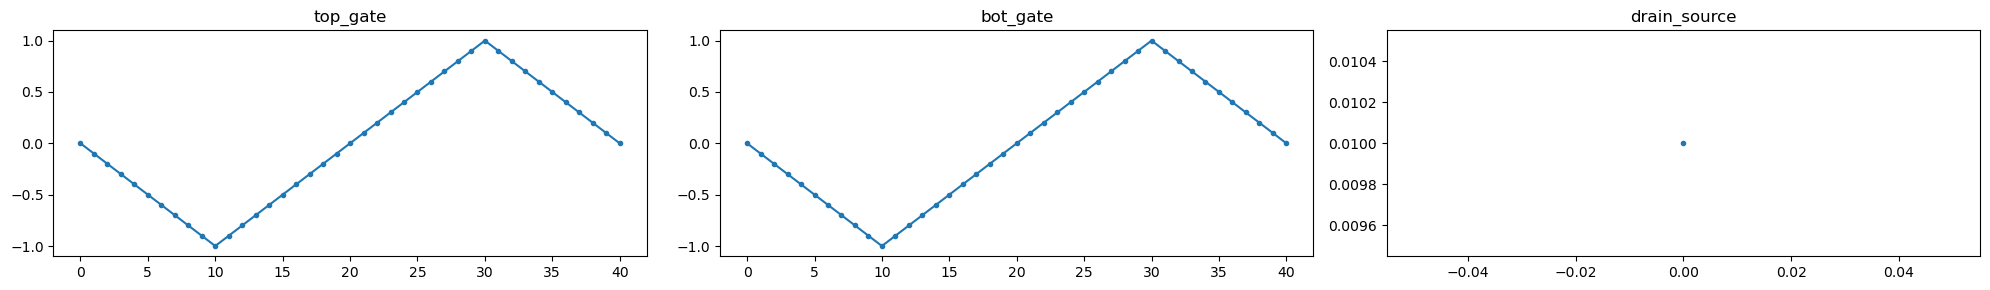

In [7]:
#####set scan lists and plot
i = 0
fig = plt.figure(figsize=(20, 3))
for sweeper in sweepers:
    startvoltage = sweeper["start"]
    firstnode = sweeper["first_node"]
    secondnode = sweeper["second_node"]
    step = sweeper["step"]

    if step == 0:
        sweeper["scan_range"] = [startvoltage]
    else:
        n = 1+abs(int((firstnode-startvoltage)/step))
        scan_range1 = np.linspace(startvoltage,firstnode,n)
        scan_range1 = scan_range1[:-1] #remove duplicate point

        n = 1+abs(int((secondnode-firstnode)/step))
        scan_range2 = np.linspace(firstnode,secondnode,n)
        scan_range2 = scan_range2[:-1] #remove duplicate point

        n = 1+abs(int((startvoltage-secondnode)/step))
        scan_range3 = np.linspace(secondnode,startvoltage,n)
    
        sweeper["scan_range"] = np.concatenate((scan_range1,scan_range2, scan_range3))    
        print(sweeper["scan_range"])

    if sweeper["manual"]:
        sweeper["scan_range"] = sweeper["manual_scanrange"]


    ax = fig.add_subplot(1,len(sweepers),i+1)
    ax.plot(sweeper["scan_range"], marker = '.')
    ax.set_title(sweeper["name"])
    i+=1

fig.tight_layout()

In [8]:
def set_ktime(dt_in = dt_list[0], ktime_control = True):
    if not ktime_control:
        return
    nplc_set = dt_in*50*(1-delayNPLC_ratio)
    delay = dt_in - (nplc_set/50)

    for sweeper in sweepers_save_order:
        sweeper["channel"].delay(delay)
        sweeper["channel"].nplc(nplc_set)

In [9]:
set_ktime(dt_list[0],ktime_control=ktime_control)

In [10]:
#----Connect to database----#
db_path.mkdir(parents = True, exist_ok = True)
initialise_or_create_database_at(f'{db_save_path}{device_name}_arbSweeper.db')
#Set up experiment object
test_exp = load_or_create_experiment(
    experiment_name=xpmnt_name,
    sample_name=device_name,
)

meas_forward, time, independent_params = setup_database_registers_arb(station, test_exp, sweepers_save_order, time_independent=time_independent)
meas_forward.write_period = write_period


In [11]:
#ramp voltages to initial values, from 0
#initial values: 
if ramp_up:
    for sweeper in sweepers:
        print(f'ramping {sweeper["name"]} to {sweeper["scan_range"][0]}')
        ramp_voltage(sweeper["channel"], sweeper["scan_range"][0])

print(f'Delay for {start_delay} s...')
sleep(start_delay)
print("Starting sweeps")
time.reset_clock()

for sweeper in sweepers:
    if sweeper["mode"] == "i":
        ch = sweeper["channel"]
        trigger_fns.source_trig_params(ch)
        trigger_fns.meas_trig_params(ch)
    else:
        ch = sweeper["channel"]
        trigger_fns_v.source_trig_params(ch)
        trigger_fns_v.meas_trig_params(ch)

channels = [s["channel"] for s in sweepers]
    

scan_ranges = [d["scan_range"] for d in sweepers]
with meas_forward.run() as forward_saver:
    for dt_in in dt_list:
        set_ktime(dt_in,ktime_control)
        for rep in range(repeat):
            print(f'Repeat: {rep}')
            first_sweep = True            
            for scan_range in itertools.product(*scan_ranges):
                for x,sweeper in zip(scan_range,sweepers):
                    if sweeper["mode"] == "i":
                        trigger_fns.set_v(sweeper["channel"],x)
                    else:
                        trigger_fns_v.set_i(sweeper["channel"],x*1e-9)

                if rep >  0 and first_sweep:
                        first_sweep = False    
                        continue
                
                t = time()
                get_readings = []
                independent_params = []

                trigger_fns.trigger(keithleys, channels)
                
                for sweeper in sweepers_save_order:
                    if sweeper["mode"] != "i":
                        v, j = trigger_fns.recall_buffer(sweeper["channel"])
                        v = float(v)
                        j = float(j)
                        get_readings.append((sweeper["channel"].curr, j))

                        if sweeper["independent"]:
                            independent_params.append((sweeper["channel"].volt, v))

                        if not sweeper["independent"]:
                            get_readings.append((sweeper["channel"].volt, v))

                        if "temperature" in sweeper["name"]:
                            temperature = rToT(v/j)
                            get_readings.append((sweeper["channel"].temperature, temperature))
                    else:
                        j, v = trigger_fns_v.recall_buffer(sweeper["channel"])
                        v = float(v)
                        j = float(j)
                        get_readings.append((sweeper["channel"].volt, v))

                        if sweeper["independent"]:
                            independent_params.append((sweeper["channel"].curr, j))

                        if not sweeper["independent"]:
                            get_readings.append((sweeper["channel"].curr, j))

                        
                forward_saver.add_result(
                    *independent_params,
                    *get_readings,
                    (time, t)
                    )
            
data_forward = forward_saver.dataset

#save data to csv
csv_path.mkdir(parents = True, exist_ok = True)
data_forward.to_pandas_dataframe().to_csv(f"{csv_save_path}{device_name}{xpmnt_name}_{data_forward.run_id}_manual_sweep.csv")

# Ramping voltage back to 0



Delay for 1 s...
Starting sweeps
Starting experimental run with id: 23. 
Repeat: 0


An exception occurred in measurement with guid: bcb4a858-0000-0000-0000-019ed685cffe;
Traceback:
Traceback (most recent call last):
  File "C:\Users\Eli Hoenig\AppData\Local\Temp\ipykernel_21144\344283983.py", line 67, in <module>
    j, v = trigger_fns_v.recall_buffer(sweeper["channel"])
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Eli Hoenig\Documents\Python Scripts\pyKeithleyControl_trigger\scripts\trigger_fns_v.py", line 42, in recall_buffer
    j = ch.ask(f"{ch.channel}.nvbuffer1.readings[1]")
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Eli Hoenig\anaconda3\envs\k_control\Lib\site-packages\qcodes\instrument\channel.py", line 66, in ask
    return self._parent.ask(cmd)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Eli Hoenig\Documents\Python Scripts\pyKeithleyControl_trigger\scripts\Keithley_2600.py", line 1013, in ask
    return super().ask(f"print({cmd:s})")
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Eli

Received SIGINT, Will interrupt at first suitable time. Send second SIGINT to interrupt immediately.


KeyboardInterrupt: 

In [ ]:
if ramp_down:
    for sweeper in sweepers:
        if not "nano" in sweeper["name"]:
            print(f'ramping {sweeper["name"]} to 0')
            ramp_voltage(sweeper["channel"], 0)

ramping top_gate to 0
ramping <Keithley2600Channel: keithley1_smub of Keithley2600: keithley1> from -0.300038 to 0
ramping drain_source to 0
ramping <Keithley2600Channel: keithley1_smua of Keithley2600: keithley1> from 0.0102615 to 0
